# Results


In [2]:
# %load imports.py
%load_ext autoreload
%autoreload 2
%load_ext kedro.extras.extensions.ipython
%reload_kedro 
%config Completer.use_jedi = False  ## (To fix autocomplete)

import pandas as pd

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

from vessel_manoeuvring_models.models.vmm import ModelSimulator
import matplotlib.pyplot as plt

%matplotlib inline
from vessel_manoeuvring_models.visualization.plot import track_plots, plot, captive_plot
import kedro
import numpy as np
import os.path
import anyconfig

import matplotlib

matplotlib.rcParams["figure.figsize"] = (15, 4)

from myst_nb import glue
from vessel_manoeuvring_models.symbols import *
import vessel_manoeuvring_models.symbols as symbols
from vessel_manoeuvring_models.system_equations import *

from IPython.display import display, Math, Latex, Markdown
from sympy.physics.vector.printing import vpprint, vlatex

from vessel_manoeuvring_models.parameters import df_parameters

p = df_parameters["symbol"]

# Read configs:
conf_path = os.path.join("../conf/base/")
runs_globals_path = os.path.join(
    conf_path,
    "runs_globals.yml",
)

runs_globals = anyconfig.load(runs_globals_path)
model_test_ids = runs_globals["model_test_ids"]

join_globals_path = os.path.join(
    conf_path,
    "join_globals.yml",
)

joins = runs_globals["joins"]
join_runs_dict = anyconfig.load(join_globals_path)

globals_path = os.path.join(
    conf_path,
    "globals.yml",
)
global_variables = anyconfig.load(globals_path)


vmm_names = global_variables["vmms"]

ship_data = catalog.load("wpcc.ship_data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The kedro.extras.extensions.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.extras.extensions.ipython
2026-05-20 15:00:57,374 - kedro.framework.session.store - INFO - `read()` not implemented for `SQLiteStore`. Assuming empty store.


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/kedro/framework/context/context.py:488: UserWarning: Credentials not found in your Kedro project config.
No files found in ['/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/base', '/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/conf/local'] matching the glob pattern(s): ['credentials*', 'credentials*/**', '**/credentials*']
  warn(f"Credentials not found in your Kedro project config.\n{str(exc)}")


2026-05-20 15:00:58,453 - root - INFO - ** Kedro project wPCC_pipeline
2026-05-20 15:00:58,455 - root - INFO - Defined global variable `context`, `session`, `catalog` and `pipelines`
2026-05-20 15:00:58,471 - root - INFO - Registered line magic `run_viz`


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/mistune.py:435: DeprecationWarning: invalid escape sequence '\|'
  cells[i][c] = re.sub('\\\\\|', '|', cell)
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/jupyter_sphinx/utils.py:43: DeprecationWarning: invalid escape sequence '\('
  """Remove LaTeX math delimiters that would be rendered by the math block.


2026-05-20 15:01:00,244 - kedro.io.data_catalog - INFO - Loading data from `wpcc.ship_data` (YAMLDataSet)...


In [3]:
runs_meta_data = catalog.load("wpcc.runs_meta_data")
model_test_ids = [int(value) for value in model_test_ids["wpcc"]]
mask = runs_meta_data.index.isin(model_test_ids)
runs_meta_data = runs_meta_data.loc[mask].copy()

2026-05-20 15:01:03,141 - kedro.io.data_catalog - INFO - Loading data from `wpcc.runs_meta_data` (CSVDataSet)...


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


In [4]:
runs_meta_data

,ship_speed,comment,test_type,angle1,description
22639,0.641180,8.0 kn,reference speed,NaN,Reference speed 0.6 m/s
22635,0.801475,10.0 kn,reference speed,NaN,Reference speed 0.8 m/s
22611,0.961770,12.0 kn,reference speed,NaN,Reference speed 1.0 m/s
22770,0.961770,ZZ 10/10PS,zigzag,10.0,ZigZag10/10
22773,0.961770,ZZ 20/20PS,zigzag,20.0,ZigZag20/20
22772,0.961770,ZZ 20/20SB,zigzag,20.0,ZigZag20/20


In [5]:
runs_meta_data["comment"].unique()

array(['8.0 kn', '10.0 kn', '12.0 kn', 'ZZ 10/10PS', 'ZZ 20/20PS',
       'ZZ 20/20SB'], dtype=object)

In [6]:
def mirror(df):

    df["y0"] *= -1
    df["psi"] *= -1
    df["v"] *= -1
    df["r"] *= -1
    df["v1d"] *= -1
    df["r1d"] *= -1
    df["delta"] *= -1

    return df

In [9]:
descriptions = ["ZigZag10/10", "ZigZag20/20"]#, "Turning circle"]
run_groups = runs_meta_data.groupby(by="description")

dataframes_all = {}

for description in descriptions:
    dataframes = dataframes_all[description] = {}
    df_ = run_groups.get_group(description)
    for id, row in df_.iterrows():
        data_ = catalog.load(f"wpcc.updated.{id}.data_ek_smooth")

        if "PS" in row["comment"]:
            data_ = mirror(data_)

        dataframes[id] = data_

2026-05-20 15:01:52,436 - kedro.io.data_catalog - INFO - Loading data from `wpcc.updated.22770.data_ek_smooth` (CSVDataSet)...
2026-05-20 15:01:52,498 - kedro.io.data_catalog - INFO - Loading data from `wpcc.updated.22773.data_ek_smooth` (CSVDataSet)...
2026-05-20 15:01:52,563 - kedro.io.data_catalog - INFO - Loading data from `wpcc.updated.22772.data_ek_smooth` (CSVDataSet)...


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(
/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_

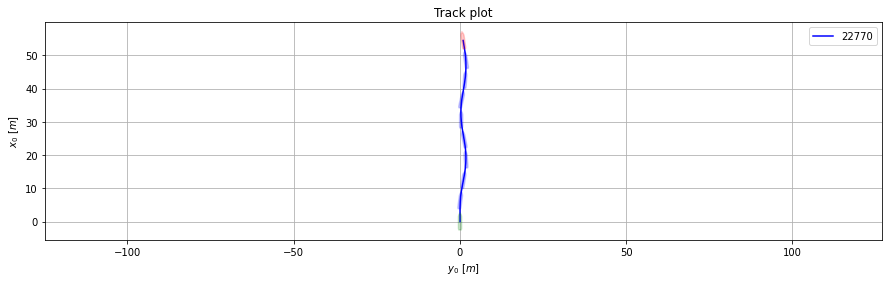

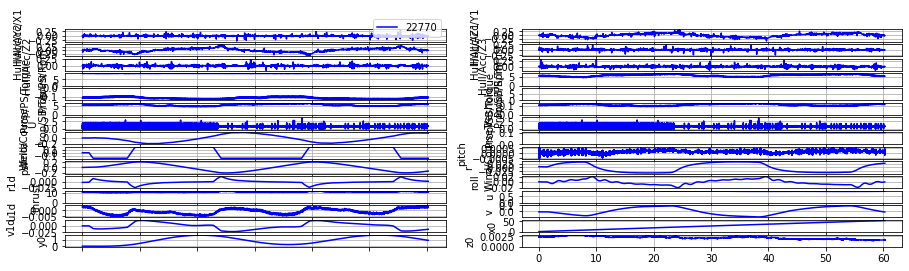

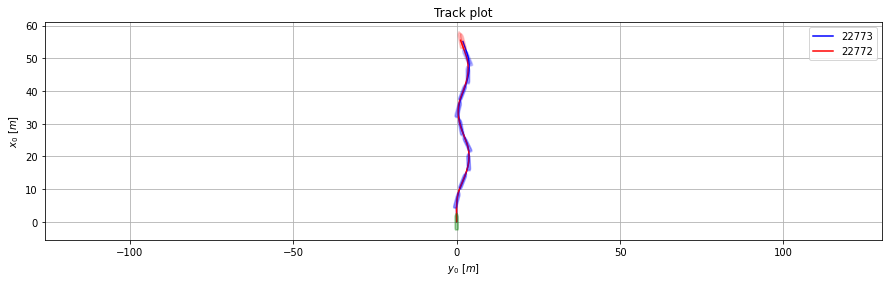

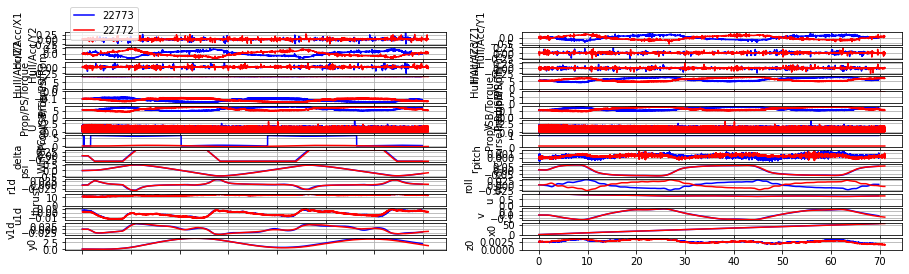

In [10]:
for description, dataframes in dataframes_all.items():
    track_plots(dataframes, lpp=ship_data["L"], beam=ship_data["B"])
    plot(dataframes)

In [11]:
descriptions = ["ZigZag10/10", "ZigZag20/20"]#, "Turning circle"]
mask = runs_meta_data["description"].isin(descriptions)
runs_meta_data = runs_meta_data.loc[mask]
mask = runs_meta_data.duplicated(subset="description", keep="last")
runs = runs_meta_data.loc[~mask].copy()
runs

/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


,ship_speed,comment,test_type,angle1,description
22770,0.96177,ZZ 10/10PS,zigzag,10.0,ZigZag10/10
22772,0.96177,ZZ 20/20SB,zigzag,20.0,ZigZag20/20


In [13]:
dataframes_all = {}
vmm_name = "vmm_abkowitz_simple"

dataframes_all = {}

for id, row in runs.iterrows():
    dataframes = dataframes_all[row["description"]] = {}

    data_smooth = catalog.load(f"wpcc.updated.{id}.data_ek_smooth")
    data_sim = catalog.load(f"{vmm_name}.motion_regression.joined.{id}.data_resimulate")

    dataframes["model test"] = data_smooth
    dataframes[vmm_name] = data_sim

2026-05-20 15:02:41,635 - kedro.io.data_catalog - INFO - Loading data from `wpcc.updated.22770.data_ek_smooth` (CSVDataSet)...


/home/sim/Documents/git_repos/SI_VMM/System-identification-of-Vessel-Manoeuvring-Models/.venv/lib/python3.10/site-packages/pandas/core/algorithms.py:517: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type(


DataSetNotFoundError: DataSet 'vmm_abkowitz_simple.motion_regression.joined.22770.data_resimulate' not found in the catalog - did you mean one of these instead: wpcc.updated.vmm_abkowitz.joined.22770.data_resimulate, wpcc.initial.vmm_abkowitz.joined.22770.data_resimulate, wpcc.updated.vmm_martins_simple.joined.22770.data_resimulate

In [ ]:
for description, dataframes in dataframes_all.items():
    track_plots(dataframes, lpp=ship_data["L"], beam=ship_data["B"], plot_boats=False)
    plot(dataframes, keys=["psi", "u", "v", "r"])


In [ ]:
%reload_kedro
df_ = catalog.load(f"kvlcc2.{id}.raw_data")